# Week 13. Мини-аналитика: поиск аномалий в динамике GDP

В проекте используется временной ряд GDP (current US$) для России из World Bank. Для простой ML-модели данных мало: один объект наблюдения по годам и почти нет независимых признаков. Поэтому для задания выбран вариант B — поиск аномалий эвристическим методом.

## B1. Постановка задачи

**Метрика:** годовой темп изменения GDP, `%`.

**Аномалия:** год, в котором темп изменения GDP сильно отличается от обычной динамики ряда.

**Практический смысл:** такие годы стоит отдельно проверить в аналитике: это может быть экономический кризис, резкий рост, эффект курса валют или ошибка/особенность данных.

## Загрузка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

def load_state(state_path: str = "../data/state/state.json") -> dict:
    path = Path(state_path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    else:
        raise FileNotFoundError(f"state.json not found: {path}")

state = load_state()
TIMESTAMP = state["timestamp"]
data_path = f"../data/mart/variant_09/mart_yearly_{TIMESTAMP}.csv"

sns.set_theme(style="whitegrid")

df = pd.read_csv(data_path)
df.head()

,year,country_name,gdp,gdp_diff,gdp_growth_pct
0,2024,Россия,2173.84,NaN,NaN
1,2023,Россия,2071.51,-102.33,-4.71
2,2022,Россия,2291.61,220.11,10.63
3,2021,Россия,1829.19,-462.43,-20.18
4,2020,Россия,1493.08,-336.11,-18.37


In [2]:
growth = (
    df.dropna(subset=["gdp_growth_pct"])
    .rename(columns={"gdp_growth_pct": "growth_pct"})
    .copy()
)

growth.head()

,year,country_name,gdp,gdp_diff,growth_pct
1,2023,Россия,2071.51,-102.33,-4.71
2,2022,Россия,2291.61,220.11,10.63
3,2021,Россия,1829.19,-462.43,-20.18
4,2020,Россия,1493.08,-336.11,-18.37
5,2019,Россия,1693.12,200.04,13.40


## B2. Метод: Z-score

Используем Z-score: смотрим, насколько значение отличается от среднего в единицах стандартного отклонения. Так как ряд короткий и годовые макропоказатели часто имеют сильные скачки, берем умеренный порог `|z| > 1.5`.

In [7]:
z_threshold = 1.5

mean_growth = growth["growth_pct"].mean()
std_growth = growth["growth_pct"].std()
growth["z_score"] = (growth["growth_pct"] - mean_growth) / std_growth
growth["is_anomaly"] = growth["z_score"].abs() > z_threshold

lower_bound = mean_growth - z_threshold * std_growth
upper_bound = mean_growth + z_threshold * std_growth

method_summary = pd.DataFrame(
    {
        "mean_growth_pct": [mean_growth],
        "std_growth_pct": [std_growth],
        "z_threshold": [z_threshold],
        "lower_bound": [lower_bound],
        "upper_bound": [upper_bound],
    }
)

method_summary.round(2)

,mean_growth_pct,std_growth_pct,z_threshold,lower_bound,upper_bound
0,-1.79,20.69,1.5,-32.82,29.24


## B3. Оценка без target

Посчитаем количество аномалий и выведем самые сильные отклонения.

In [8]:
anomalies = growth[growth["is_anomaly"]].copy()
anomalies["abs_growth_pct"] = anomalies["growth_pct"].abs()

print(f"Всего наблюдений: {len(growth)}")
print(f"Найдено аномалий: {len(anomalies)}")

anomalies[["year", "country_name", "gdp", "growth_pct", "z_score"]].sort_values(
    "z_score",
    key=lambda s: s.abs(),
    ascending=False,
).round(2)

Всего наблюдений: 36
Найдено аномалий: 4


,year,country_name,gdp,growth_pct,z_score
10,2014,Россия,2059.24,51.03,2.55
27,1997,Россия,404.93,49.44,2.48
26,1998,Россия,270.96,38.31,1.94
16,2008,Россия,1660.85,35.84,1.82


Построим временной ряд GDP growth и выделим найденные аномалии.

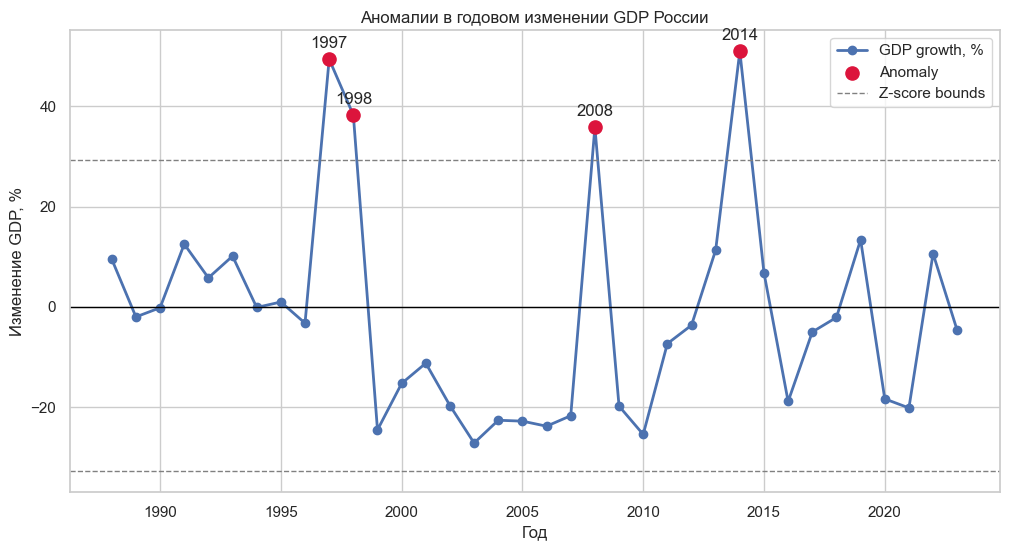

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(growth["year"], growth["growth_pct"], marker="o", linewidth=2, label="GDP growth, %")
ax.scatter(
    anomalies["year"],
    anomalies["growth_pct"],
    color="crimson",
    s=90,
    zorder=3,
    label="Anomaly",
)

ax.axhline(lower_bound, color="gray", linestyle="--", linewidth=1, label="Z-score bounds")
ax.axhline(upper_bound, color="gray", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=1)

for _, row in anomalies.iterrows():
    ax.annotate(
        int(row["year"]),
        (row["year"], row["growth_pct"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

ax.set_title("Аномалии в годовом изменении GDP России")
ax.set_xlabel("Год")
ax.set_ylabel("Изменение GDP, %")
ax.legend()
plt.show()

Посмотрим топ лет по модулю изменения GDP, даже если часть из них не прошла строгий IQR-порог.

In [6]:
top_changes = growth.assign(abs_growth_pct=growth["growth_pct"].abs()).sort_values(
    "abs_growth_pct",
    ascending=False,
)

top_changes[["year", "country_name", "gdp", "growth_pct", "z_score", "is_anomaly"]].head(10).round(2)

,year,country_name,gdp,growth_pct,z_score,is_anomaly
10,2014,Россия,2059.24,51.03,2.55,True
27,1997,Россия,404.93,49.44,2.48,True
26,1998,Россия,270.96,38.31,1.94,True
16,2008,Россия,1660.85,35.84,1.82,True
21,2003,Россия,430.35,-27.19,-1.23,False
14,2010,Россия,1524.92,-25.47,-1.14,False
25,1999,Россия,195.91,-24.57,-1.10,False
18,2006,Россия,989.93,-23.83,-1.07,False
19,2005,Россия,764.02,-22.82,-1.02,False
20,2004,Россия,591.02,-22.64,-1.01,False


## Интерпретация

Резкие изменения GDP в текущих долларах США не всегда означают только изменение реального объема экономики. На показатель влияют инфляция, курс валют, внешние шоки и методология публикации данных. Поэтому найденные точки стоит трактовать как годы для дополнительной аналитической проверки, а не как автоматическую ошибку данных.

## B4. Вывод: полезно или нет

Метод Z-score полезен для проекта как простой аналитический контроль. Он помогает быстро найти годы с необычной динамикой GDP и сфокусировать дальнейший анализ на них.

Ограничения метода:

- данных немного, поэтому границы чувствительны к отдельным экстремальным годам;
- GDP в current US$ зависит от валютного курса и цен, поэтому аномалия может быть экономическим событием, а не ошибкой;
- без target нельзя оценить качество как у supervised ML-модели.

Что улучшить дальше:

- сравнить GDP growth с другими странами или регионами;
- добавить показатели inflation, exchange rate, GDP per capita;
- использовать rolling z-score, чтобы учитывать локальный контекст временного ряда.